# Problem 1 - Transformer Character-Level Model


## Colab Setup
This cell installs lightweight helper packages, imports PyTorch, fixes random seeds, creates an `outputs/` folder, and selects GPU automatically when Colab provides one.


In [1]:
import importlib, subprocess, sys

def ensure_package(import_name, pip_name=None):
    pip_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

for import_name, pip_name in [
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("tqdm", "tqdm"),
    ("nltk", "nltk"),
]:
    ensure_package(import_name, pip_name)

import json, math, os, random, re, time, urllib.request
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm import tqdm

SEED = 4106
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


Using device: cuda


## Assignment Text and Character Encoding
The paragraph is embedded directly from the Homework 4 PDF so the notebook does not depend on external files.


In [2]:
TEXT = "Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text. At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model. One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks. Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time. Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants. In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology."
chars = sorted(set(TEXT))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
encoded = [stoi[ch] for ch in TEXT]
print("Characters:", len(TEXT), "Vocabulary:", len(chars))


Characters: 2386 Vocabulary: 44


## Transformer Model and Metrics
The model is a causal character-level Transformer. Validation accuracy is token-level next-character accuracy on held-out windows. Complexity is reported as approximate multiply-adds per input sequence.


In [3]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_size_mb(model):
    return count_parameters(model) * 4 / (1024 ** 2)

def transformer_madds_per_sequence(seq_len, d_model, n_layers, dim_ff, vocab_size):
    # Approximate multiply-adds for one causal Transformer sequence.
    # Per encoder block: Q/K/V/O projections, attention score/value products, and two FFN projections.
    per_layer = 4 * seq_len * d_model * d_model + 2 * seq_len * seq_len * d_model + 2 * seq_len * d_model * dim_ff
    output_head = seq_len * d_model * vocab_size
    return int(n_layers * per_layer + output_head)

class CharWindowDataset(Dataset):
    def __init__(self, encoded, seq_len):
        self.x = []
        self.y = []
        for i in range(len(encoded) - seq_len):
            self.x.append(torch.tensor(encoded[i:i+seq_len], dtype=torch.long))
            self.y.append(torch.tensor(encoded[i+1:i+seq_len+1], dtype=torch.long))
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

class CausalCharTransformer(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model=128, n_heads=4, n_layers=2, dim_ff=256, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.d_model = d_model
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(seq_len, d_model)
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.lm_head = nn.Linear(d_model, vocab_size)
    def forward(self, idx):
        batch_size, seq_len = idx.shape
        positions = torch.arange(seq_len, device=idx.device).unsqueeze(0).expand(batch_size, seq_len)
        x = self.token_embedding(idx) + self.position_embedding(positions)
        mask = torch.triu(torch.ones(seq_len, seq_len, device=idx.device), diagonal=1).bool()
        x = self.encoder(x, mask=mask)
        return self.lm_head(x)

def evaluate_char_model(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_tokens = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits.reshape(-1, logits.size(-1)), yb.reshape(-1))
            total_loss += loss.item() * yb.numel()
            pred = logits.argmax(dim=-1)
            total_correct += (pred == yb).sum().item()
            total_tokens += yb.numel()
    return total_loss / total_tokens, total_correct / total_tokens

def train_char_model(model, train_loader, val_loader, epochs=20, lr=3e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = []
    start = time.perf_counter()
    for epoch in tqdm(range(1, epochs + 1), desc="Training", leave=False):
        model.train()
        train_loss_sum, train_tokens = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits.reshape(-1, logits.size(-1)), yb.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss_sum += loss.item() * yb.numel()
            train_tokens += yb.numel()
        val_loss, val_acc = evaluate_char_model(model, val_loader, criterion)
        history.append({
            "epoch": epoch,
            "train_loss": train_loss_sum / train_tokens,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "val_perplexity": math.exp(min(val_loss, 20)),
        })
    train_seconds = time.perf_counter() - start
    return history, train_seconds

@torch.no_grad()
def generate_text(model, stoi, itos, start_text, length=200, temperature=0.8):
    model.eval()
    ids = [stoi.get(ch, 0) for ch in start_text]
    for _ in range(length):
        context = torch.tensor([ids[-model.seq_len:]], dtype=torch.long, device=device)
        logits = model(context)[0, -1] / temperature
        probs = torch.softmax(logits, dim=-1)
        next_id = int(torch.multinomial(probs, num_samples=1).item())
        ids.append(next_id)
    return "".join(itos[i] for i in ids)


## Run Sequence Lengths 10, 20, and 30
Each run uses an 80/20 train/validation split of the available character windows. The metrics are written to CSV/JSON and a loss-curve figure for the report.


,model,seq_len,blocks,heads,d_model,train_loss,val_loss,val_accuracy,val_perplexity,train_seconds,inference_seconds,params,model_mb,madds_per_sequence,sample_output
0,Transformer,10,2,4,128,0.813644,0.837200,0.727731,2.309890,20.151883,0.025770,277548,1.058762,2728960,Next character predictions maintain sequence o...
1,Transformer,20,2,4,128,0.493278,0.437073,0.857911,1.548169,17.201714,0.025215,278828,1.063644,5560320,Next character prediction tasks. Training algo...
2,Transformer,30,2,4,128,0.380629,0.304135,0.900636,1.355451,18.276728,0.029970,280108,1.068527,8494080,Next character prediction tasks. Training a mo...


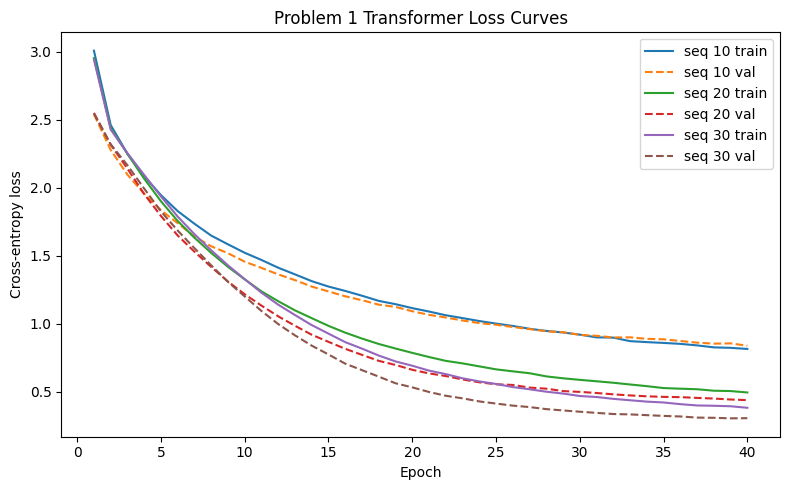

In [4]:
CONFIG = dict(d_model=128, n_heads=4, n_layers=2, dim_ff=256, dropout=0.1, epochs=40, batch_size=32, lr=3e-4)
results = []
histories = {}
for seq_len in [10, 20, 30]:
    dataset = CharWindowDataset(encoded, seq_len)
    n_train = int(0.8 * len(dataset))
    n_val = len(dataset) - n_train
    train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False)
    model = CausalCharTransformer(
        vocab_size=len(chars), seq_len=seq_len, d_model=CONFIG["d_model"],
        n_heads=CONFIG["n_heads"], n_layers=CONFIG["n_layers"],
        dim_ff=CONFIG["dim_ff"], dropout=CONFIG["dropout"]
    ).to(device)
    history, train_seconds = train_char_model(model, train_loader, val_loader, epochs=CONFIG["epochs"], lr=CONFIG["lr"])
    final = history[-1]
    inference_start = time.perf_counter()
    _ = evaluate_char_model(model, val_loader, nn.CrossEntropyLoss())
    inference_seconds = time.perf_counter() - inference_start
    row = {
        "model": "Transformer",
        "seq_len": seq_len,
        "blocks": CONFIG["n_layers"],
        "heads": CONFIG["n_heads"],
        "d_model": CONFIG["d_model"],
        "train_loss": final["train_loss"],
        "val_loss": final["val_loss"],
        "val_accuracy": final["val_accuracy"],
        "val_perplexity": final["val_perplexity"],
        "train_seconds": train_seconds,
        "inference_seconds": inference_seconds,
        "params": count_parameters(model),
        "model_mb": model_size_mb(model),
        "madds_per_sequence": transformer_madds_per_sequence(seq_len, CONFIG["d_model"], CONFIG["n_layers"], CONFIG["dim_ff"], len(chars)),
        "sample_output": generate_text(model, stoi, itos, "Next character", length=180),
    }
    results.append(row)
    histories[seq_len] = history

results_df = pd.DataFrame(results)
display(results_df)
results_df.to_csv(OUTPUT_DIR / "problem1_transformer_metrics.csv", index=False)
(OUTPUT_DIR / "problem1_transformer_metrics.json").write_text(json.dumps(results, indent=2), encoding="utf-8")

plt.figure(figsize=(8, 5))
for seq_len, history in histories.items():
    h = pd.DataFrame(history)
    plt.plot(h["epoch"], h["train_loss"], label=f"seq {seq_len} train")
    plt.plot(h["epoch"], h["val_loss"], "--", label=f"seq {seq_len} val")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Problem 1 Transformer Loss Curves")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "problem1_loss_curves.png", dpi=160)
plt.show()


## Homework 2 RNN Comparison Data
These are verified prior RNN/LSTM/GRU results extracted from the Homework 2 report. Use this table beside the Transformer table in the final write-up.


In [5]:
hw2_rows = [["GRU", 10, 0.484, 2.9929, 0.4795, 19.94, 3.91, 0.0094, 83181, 0.317, 794880], ["LSTM", 10, 0.4904, 2.7791, 0.4848, 16.11, 4.33, 0.0095, 108013, 0.412, 1040640], ["RNN", 10, 0.5165, 2.9744, 0.4735, 19.58, 4.47, 0.0111, 33517, 0.128, 303360], ["GRU", 20, 0.2518, 3.2493, 0.497, 25.77, 3.68, 0.0088, 83181, 0.317, 1589760], ["LSTM", 20, 0.2588, 3.0586, 0.4949, 21.3, 4.36, 0.0094, 108013, 0.412, 2081280], ["RNN", 20, 0.2741, 3.1901, 0.4844, 24.29, 3.58, 0.0121, 33517, 0.128, 606720], ["GRU", 30, 0.1705, 3.3001, 0.5074, 27.12, 3.9, 0.009, 83181, 0.317, 2384640], ["LSTM", 30, 0.1767, 3.189, 0.5053, 24.26, 4.85, 0.009, 108013, 0.412, 3121920], ["RNN", 30, 0.1881, 3.454, 0.4855, 31.63, 3.51, 0.0079, 33517, 0.128, 910080]]
hw2_df = pd.DataFrame(hw2_rows, columns=["model", "seq_len", "train_loss", "val_loss", "val_accuracy", "val_perplexity", "train_seconds", "inference_seconds", "params", "model_mb", "madds_per_sequence"])
display(hw2_df)
comparison_df = pd.concat([results_df, hw2_df], ignore_index=True, sort=False)
comparison_df.to_csv(OUTPUT_DIR / "problem1_transformer_vs_hw2_rnn.csv", index=False)
display(comparison_df.sort_values(["seq_len", "model"]))


,model,seq_len,train_loss,val_loss,val_accuracy,val_perplexity,train_seconds,inference_seconds,params,model_mb,madds_per_sequence
0,GRU,10,0.4840,2.9929,0.4795,19.94,3.91,0.0094,83181,0.317,794880
1,LSTM,10,0.4904,2.7791,0.4848,16.11,4.33,0.0095,108013,0.412,1040640
2,RNN,10,0.5165,2.9744,0.4735,19.58,4.47,0.0111,33517,0.128,303360
3,GRU,20,0.2518,3.2493,0.4970,25.77,3.68,0.0088,83181,0.317,1589760
4,LSTM,20,0.2588,3.0586,0.4949,21.30,4.36,0.0094,108013,0.412,2081280
5,RNN,20,0.2741,3.1901,0.4844,24.29,3.58,0.0121,33517,0.128,606720
6,GRU,30,0.1705,3.3001,0.5074,27.12,3.90,0.0090,83181,0.317,2384640
7,LSTM,30,0.1767,3.1890,0.5053,24.26,4.85,0.0090,108013,0.412,3121920
8,RNN,30,0.1881,3.4540,0.4855,31.63,3.51,0.0079,33517,0.128,910080


,model,seq_len,blocks,heads,d_model,train_loss,val_loss,val_accuracy,val_perplexity,train_seconds,inference_seconds,params,model_mb,madds_per_sequence,sample_output
3,GRU,10,NaN,NaN,NaN,0.484000,2.992900,0.479500,19.940000,3.910000,0.009400,83181,0.317000,794880,NaN
4,LSTM,10,NaN,NaN,NaN,0.490400,2.779100,0.484800,16.110000,4.330000,0.009500,108013,0.412000,1040640,NaN
5,RNN,10,NaN,NaN,NaN,0.516500,2.974400,0.473500,19.580000,4.470000,0.011100,33517,0.128000,303360,NaN
0,Transformer,10,2.0,4.0,128.0,0.813644,0.837200,0.727731,2.309890,20.151883,0.025770,277548,1.058762,2728960,Next character predictions maintain sequence o...
6,GRU,20,NaN,NaN,NaN,0.251800,3.249300,0.497000,25.770000,3.680000,0.008800,83181,0.317000,1589760,NaN
7,LSTM,20,NaN,NaN,NaN,0.258800,3.058600,0.494900,21.300000,4.360000,0.009400,108013,0.412000,2081280,NaN
8,RNN,20,NaN,NaN,NaN,0.274100,3.190100,0.484400,24.290000,3.580000,0.012100,33517,0.128000,606720,NaN
1,Transformer,20,2.0,4.0,128.0,0.493278,0.437073,0.857911,1.548169,17.201714,0.025215,278828,1.063644,5560320,Next character prediction tasks. Training algo...
9,GRU,30,NaN,NaN,NaN,0.170500,3.300100,0.507400,27.120000,3.900000,0.009000,83181,0.317000,2384640,NaN
10,LSTM,30,NaN,NaN,NaN,0.176700,3.189000,0.505300,24.260000,4.850000,0.009000,108013,0.412000,3121920,NaN
